# Checking key4hep vs FCCAnalyses

I use the *exact same file* (`/eos/experiment/fcc/prod/fcc/ee/test_spring2024/240gev/Hbb/CLD_o2_v05/rec/00016783/000/Hbb_rec_16783_1.root`, also found here: `/afs/cern.ch/work/s/saaumill/public/analyses/symlink_Hxx_fullsim/Hxx/test`) in both cases. They should be the EXACT same. But they are not. 

In [1]:
path_1 = "/afs/cern.ch/work/s/saaumill/public/MyFCCAnalyses/outputs/treemaker/fullsimtagger_jetbased/Hbb.root"
path_2 = "/afs/cern.ch/work/s/saaumill/public/MyFCCAnalyses/outputs/treemaker/fullsimtagger_jetbased/Hbb_from_key4hep.root"

In [2]:
import uproot 
import numpy as np
import matplotlib.pyplot as plt

from helper_jetobs import *

# set the style
from cycler import cycler
import matplotlib

plt.rc('axes', prop_cycle=cycler('color', ['#73b06f', '#e6701b', '#007090', '#e7298a', '#802392', '#ffad08', '#56b4e9']))
#matplotlib.rcParams["text.usetex"] = True
matplotlib.rcParams["font.family"] = "serif"

# Set font sizes
matplotlib.rcParams.update(
    {
        "font.size": 14,  # General font size
    }
)

%load_ext autoreload
%autoreload 2

In [3]:
save_status = False  # Set to False if you do not want to save the plots

In [4]:
file_1 = uproot.open(path_1)
tree_1 = file_1["tree;1"]

file_2 = uproot.open(path_2)
tree_2 = file_2["JetConstituentObservables;1"]

# adapt the size of the data you want to load here
df_1 = tree_1.arrays(library="np", entry_start=0, entry_stop=2000) 
df_2 = tree_2.arrays(library="np", entry_start=0, entry_stop=2000)

Plot the number of constituents per jet

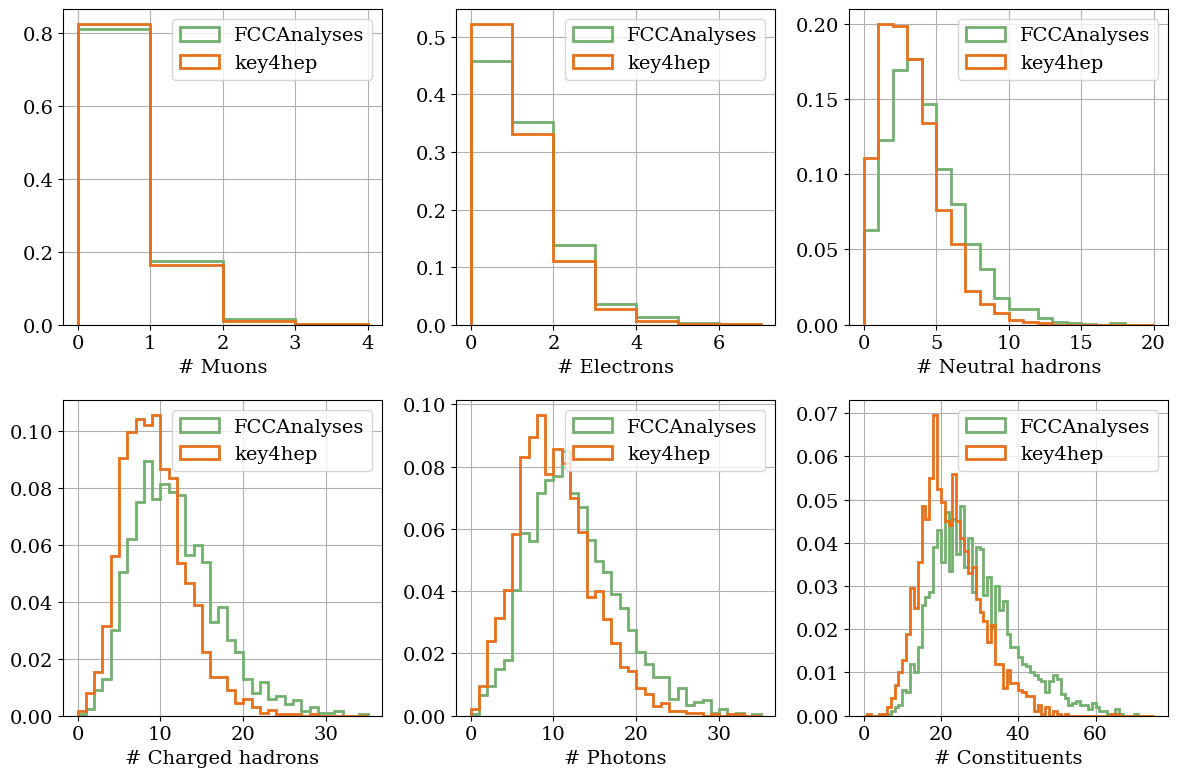

In [5]:
plot_nconst(df_1, df_2, l1="FCCAnalyses", l2="key4hep", save=save_status)

In [6]:
nconst_FCCAnalyses = np.array([len(arr) for arr in df_1["pfcand_e"]])
nconst_key4hep = np.array([len(arr) for arr in df_2["pfcand_e"]])


In [ ]:
i = 2

In [15]:
print("First nconstituent of FCCAnalyses: ", nconst_FCCAnalyses[i])
print("First nconstituent of key4hep: ", nconst_key4hep[i])

First nconstituent of FCCAnalyses:  39
First nconstituent of key4hep:  27


In [16]:
print("First nconstituent of FCCAnalyses: ", nconst_FCCAnalyses[i+1])
print("First nconstituent of key4hep: ", nconst_key4hep[i+1])

First nconstituent of FCCAnalyses:  30
First nconstituent of key4hep:  22


## Filter out the events in FCCAnalyses that are ON TOP of the ones in key4hep

In [18]:
key_map = { 
    "pfcand_erel_log": "pfcand_erel_log",
    "pfcand_thetarel": "pfcand_thetarel",
    "pfcand_phirel": "pfcand_phirel",
    "pfcand_dptdpt": "pfcand_cov_omegaomega",
    "pfcand_detadeta": "pfcand_cov_tanLambdatanLambda",
    "pfcand_dphidphi": "pfcand_cov_phiphi",
    "pfcand_dxydxy": "pfcand_cov_d0d0",
    "pfcand_dzdz": "pfcand_cov_z0z0",
    "pfcand_dxydz": "pfcand_cov_d0z0",
    "pfcand_dphidxy": "pfcand_cov_phid0",
    "pfcand_dlambdadz": "pfcand_cov_tanLambdaz0",
    "pfcand_dxyc": "pfcand_cov_d0omega",
    "pfcand_dxyctgtheta": "pfcand_cov_d0tanLambda",
    "pfcand_phic": "pfcand_cov_phiomega",
    "pfcand_phidz": "pfcand_cov_phiz0",
    "pfcand_phictgtheta": "pfcand_cov_phitanLambda",
    "pfcand_cdz": "pfcand_cov_omegaz0",
    "pfcand_cctgtheta": "pfcand_cov_omegatanLambda",
    "pfcand_dxy": "pfcand_d0",
    "pfcand_dz": "pfcand_z0",
    "pfcand_btagSip2dVal": "pfcand_Sip2dVal",
    "pfcand_btagSip2dSig": "pfcand_Sip2dSig",
    "pfcand_btagSip3dVal": "pfcand_Sip3dVal",
    "pfcand_btagSip3dSig": "pfcand_Sip3dSig",
    "pfcand_btagJetDistVal": "pfcand_JetDistVal",
    "pfcand_btagJetDistSig": "pfcand_JetDistSig",
    "pfcand_type": "pfcand_type",
    "pfcand_charge": "pfcand_charge",
    "pfcand_isEl": "pfcand_isEl",
    "pfcand_isMu": "pfcand_isMu",
    "pfcand_isGamma": "pfcand_isGamma",
    "pfcand_isChargedHad": "pfcand_isChargedHad",
    "pfcand_isNeutralHad": "pfcand_isNeutralHad",
    "pfcand_dndx": "pfcand_dndx",
    "pfcand_mtof": "pfcand_tof",
    "pfcand_e": "pfcand_e",
    "pfcand_p": "pfcand_p",
}
df_1 = {key_map.get(k): v for k, v in df_1.items() if key_map.get(k) is not None}

In [ ]:
# initialize the extra dictionary for pfcand
pfcand_extra = {}
for key in df_1.keys():
    pfcand_extra[key] = np.array([])
# an other dictionary for the pfcand without the extra values
pfcand_FCCAnalyses_minus = {}
for key in df_1.keys():
    pfcand_FCCAnalyses_minus[key] = np.array([])
# an other dictionary for the pfcand that are not key4hep but FCCanalyses
pfcand_FCCAnalyses_only = {}
for key in df_1.keys():
    pfcand_FCCAnalyses_only[key] = np.array([])


In [47]:
# loop over both df and find entries in FCCAnalyses that are not in key4hep
for i in range(2000): # 2000 jets
    # compare the momentum to two digits after the decimal point
    pfcand_FCCAnalyses_p = np.round(df_1["pfcand_p"][i], 2)
    pfcand_key4hep_p = np.round(df_2["pfcand_p"][i], 2)
    # find p's that are not in key4hep
    pfcand_FCCAnalyses_p_not_in_key4hep = np.setdiff1d(pfcand_FCCAnalyses_p, pfcand_key4hep_p)
    # check if there are any p's in key4hep that are not in FCCAnalyses
    pfcand_key4hep_p_not_in_FCCAnalyses = np.setdiff1d(pfcand_key4hep_p, pfcand_FCCAnalyses_p)
    # p's that are in both
    pfcand_p_in_both = np.intersect1d(pfcand_FCCAnalyses_p, pfcand_key4hep_p)
    # find the indices of the pfcands that are not in FCCAnalyses
    indices_not_in_key4hep = np.isin(pfcand_FCCAnalyses_p, pfcand_FCCAnalyses_p_not_in_key4hep)
    # indiecies that both have in common
    indices_in_both = np.isin(pfcand_FCCAnalyses_p, pfcand_p_in_both)

    if len(pfcand_key4hep_p_not_in_FCCAnalyses) > 0:
        print(f"Jet {i}: {len(pfcand_key4hep_p_not_in_FCCAnalyses)} pfcands in FCCAnalyses not in key4hep")
    # now add all the pfcand descriptions to the pfcand_extra dictionary (which are extra in FCCAnalyses)
    for key in df_1.keys():
        pfcand_extra[key] = np.append(pfcand_extra[key],df_1[key][i][indices_not_in_key4hep])
        pfcand_FCCAnalyses_minus[key] = np.append(pfcand_FCCAnalyses_minus[key],df_1[key][i][indices_in_both])

Jet 10: 19 pfcands in FCCAnalyses not in key4hep
Jet 11: 19 pfcands in FCCAnalyses not in key4hep
Jet 12: 11 pfcands in FCCAnalyses not in key4hep
Jet 13: 14 pfcands in FCCAnalyses not in key4hep
Jet 18: 13 pfcands in FCCAnalyses not in key4hep
Jet 19: 21 pfcands in FCCAnalyses not in key4hep
Jet 57: 13 pfcands in FCCAnalyses not in key4hep
Jet 78: 15 pfcands in FCCAnalyses not in key4hep
Jet 79: 37 pfcands in FCCAnalyses not in key4hep
Jet 87: 1 pfcands in FCCAnalyses not in key4hep
Jet 128: 24 pfcands in FCCAnalyses not in key4hep
Jet 129: 12 pfcands in FCCAnalyses not in key4hep
Jet 138: 10 pfcands in FCCAnalyses not in key4hep
Jet 139: 21 pfcands in FCCAnalyses not in key4hep
Jet 167: 2 pfcands in FCCAnalyses not in key4hep
Jet 198: 21 pfcands in FCCAnalyses not in key4hep
Jet 208: 1 pfcands in FCCAnalyses not in key4hep
Jet 220: 23 pfcands in FCCAnalyses not in key4hep
Jet 221: 18 pfcands in FCCAnalyses not in key4hep
Jet 242: 23 pfcands in FCCAnalyses not in key4hep
Jet 243: 11 p

In [28]:
# loop over keys_extra and check if all the arrays are of the same length
for key in pfcand_extra.keys():
    if len(pfcand_extra[key]) != len(pfcand_extra["pfcand_p"]):
        print(f"Key {key} has length {len(pfcand_extra[key])}, but pfcand_p has length {len(pfcand_extra['pfcand_p'])}")

In [31]:
len(pfcand_extra.keys())  # to see the keys of the extra dictionary

37

keys of pfcand_extra: ['pfcand_erel_log', 'pfcand_thetarel', 'pfcand_phirel', 'pfcand_cov_omegaomega', 'pfcand_cov_tanLambdatanLambda', 'pfcand_cov_phiphi', 'pfcand_cov_d0d0', 'pfcand_cov_z0z0', 'pfcand_cov_d0z0', 'pfcand_cov_phid0', 'pfcand_cov_tanLambdaz0', 'pfcand_cov_d0omega', 'pfcand_cov_d0tanLambda', 'pfcand_cov_phiomega', 'pfcand_cov_phiz0', 'pfcand_cov_phitanLambda', 'pfcand_cov_omegaz0', 'pfcand_cov_omegatanLambda', 'pfcand_tof', 'pfcand_dndx', 'pfcand_charge', 'pfcand_isMu', 'pfcand_isEl', 'pfcand_isChargedHad', 'pfcand_isGamma', 'pfcand_isNeutralHad', 'pfcand_d0', 'pfcand_z0', 'pfcand_Sip2dVal', 'pfcand_Sip2dSig', 'pfcand_Sip3dVal', 'pfcand_Sip3dSig', 'pfcand_JetDistVal', 'pfcand_JetDistSig', 'pfcand_type', 'pfcand_e', 'pfcand_p']


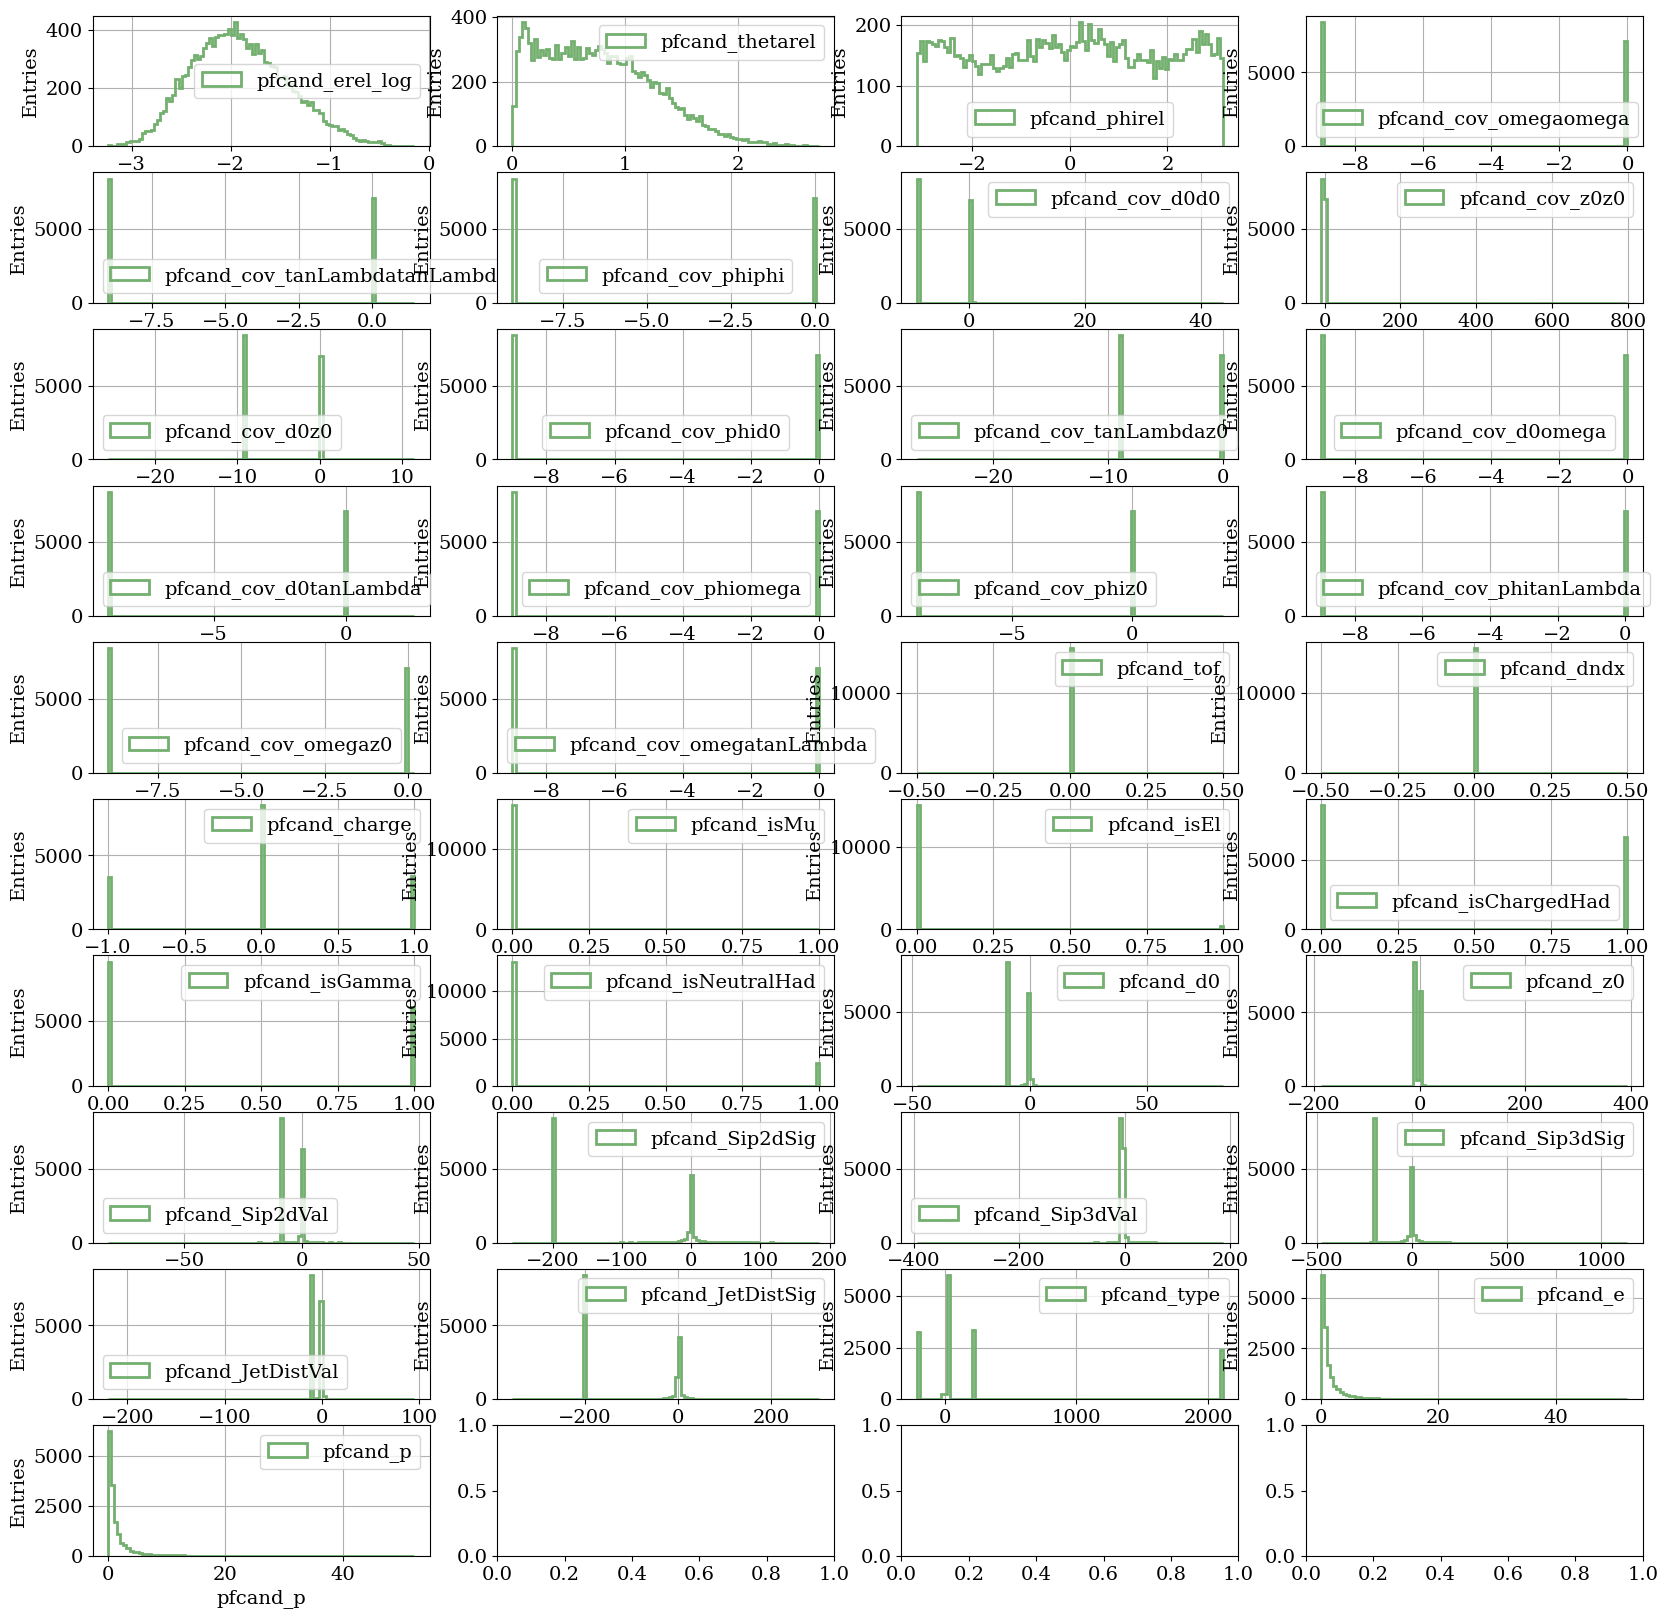

In [ ]:
# print histograms of all the extra pfcand variables
fig, axs = plt.subplots(10, 4, figsize=(20,20))
keys = list(pfcand_extra.keys())
print("keys of pfcand_extra:", keys)
for i, ax in enumerate(axs.flat):
    if i >= len(pfcand_extra.keys()):
        break
    ax.hist(pfcand_extra[keys[i]], bins=100, histtype="step", label=keys[i], density=False, linewidth=2.0)
    ax.set_xlabel(key)
    ax.set_ylabel("Entries")
    ax.legend()
    ax.grid(True)

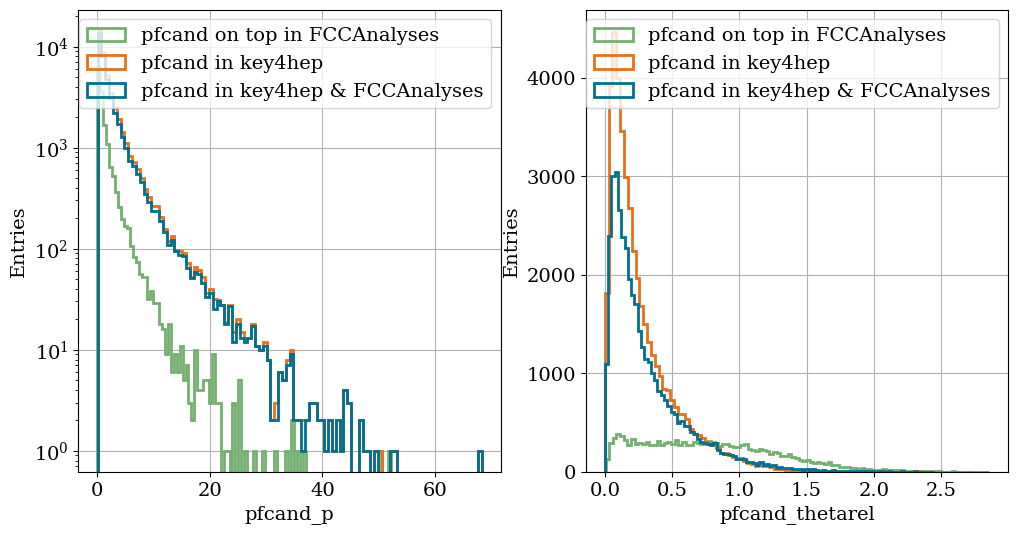

In [49]:
# plot pfcand_p and pfcand_thetarel
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].hist(pfcand_extra["pfcand_p"], bins=100, histtype="step", label="pfcand on top in FCCAnalyses", density=False, linewidth=2.0)
# also plot the distribution of pfcand_p in key4hep
axs[0].hist(np.concatenate(df_2["pfcand_p"]), bins=100, histtype="step", label="pfcand in key4hep", density=False, linewidth=2.0)
# also add plot from pfcand_FCCAnalyses_minus
axs[0].hist(pfcand_FCCAnalyses_minus["pfcand_p"], bins=100, histtype="step", label="pfcand in key4hep & FCCAnalyses", density=False, linewidth=2.0)
axs[0].legend()
axs[0].set_xlabel("pfcand_p")
axs[0].set_ylabel("Entries")
axs[0].grid(True)   
axs[0].set_yscale("log")

axs[1].hist(pfcand_extra["pfcand_thetarel"], bins=100, histtype="step", label="pfcand on top in FCCAnalyses", density=False, linewidth=2.0)
# also plot the distribution of pfcand_thetarel in key4hep
axs[1].hist(np.concatenate(df_2["pfcand_thetarel"]), bins=100, histtype="step", label="pfcand in key4hep", density=False, linewidth=2.0)
# also add plot from pfcand_FCCAnalyses_minus
axs[1].hist(pfcand_FCCAnalyses_minus["pfcand_thetarel"], bins=100, histtype="step", label="pfcand in key4hep & FCCAnalyses", density=False, linewidth=2.0)
axs[1].legend()
axs[1].set_xlabel("pfcand_thetarel")
axs[1].set_ylabel("Entries")
axs[1].grid(True)   

keys of pfcand_FCCAnalyses_minus: ['pfcand_erel_log', 'pfcand_thetarel', 'pfcand_phirel', 'pfcand_cov_omegaomega', 'pfcand_cov_tanLambdatanLambda', 'pfcand_cov_phiphi', 'pfcand_cov_d0d0', 'pfcand_cov_z0z0', 'pfcand_cov_d0z0', 'pfcand_cov_phid0', 'pfcand_cov_tanLambdaz0', 'pfcand_cov_d0omega', 'pfcand_cov_d0tanLambda', 'pfcand_cov_phiomega', 'pfcand_cov_phiz0', 'pfcand_cov_phitanLambda', 'pfcand_cov_omegaz0', 'pfcand_cov_omegatanLambda', 'pfcand_tof', 'pfcand_dndx', 'pfcand_charge', 'pfcand_isMu', 'pfcand_isEl', 'pfcand_isChargedHad', 'pfcand_isGamma', 'pfcand_isNeutralHad', 'pfcand_d0', 'pfcand_z0', 'pfcand_Sip2dVal', 'pfcand_Sip2dSig', 'pfcand_Sip3dVal', 'pfcand_Sip3dSig', 'pfcand_JetDistVal', 'pfcand_JetDistSig', 'pfcand_type', 'pfcand_e', 'pfcand_p']


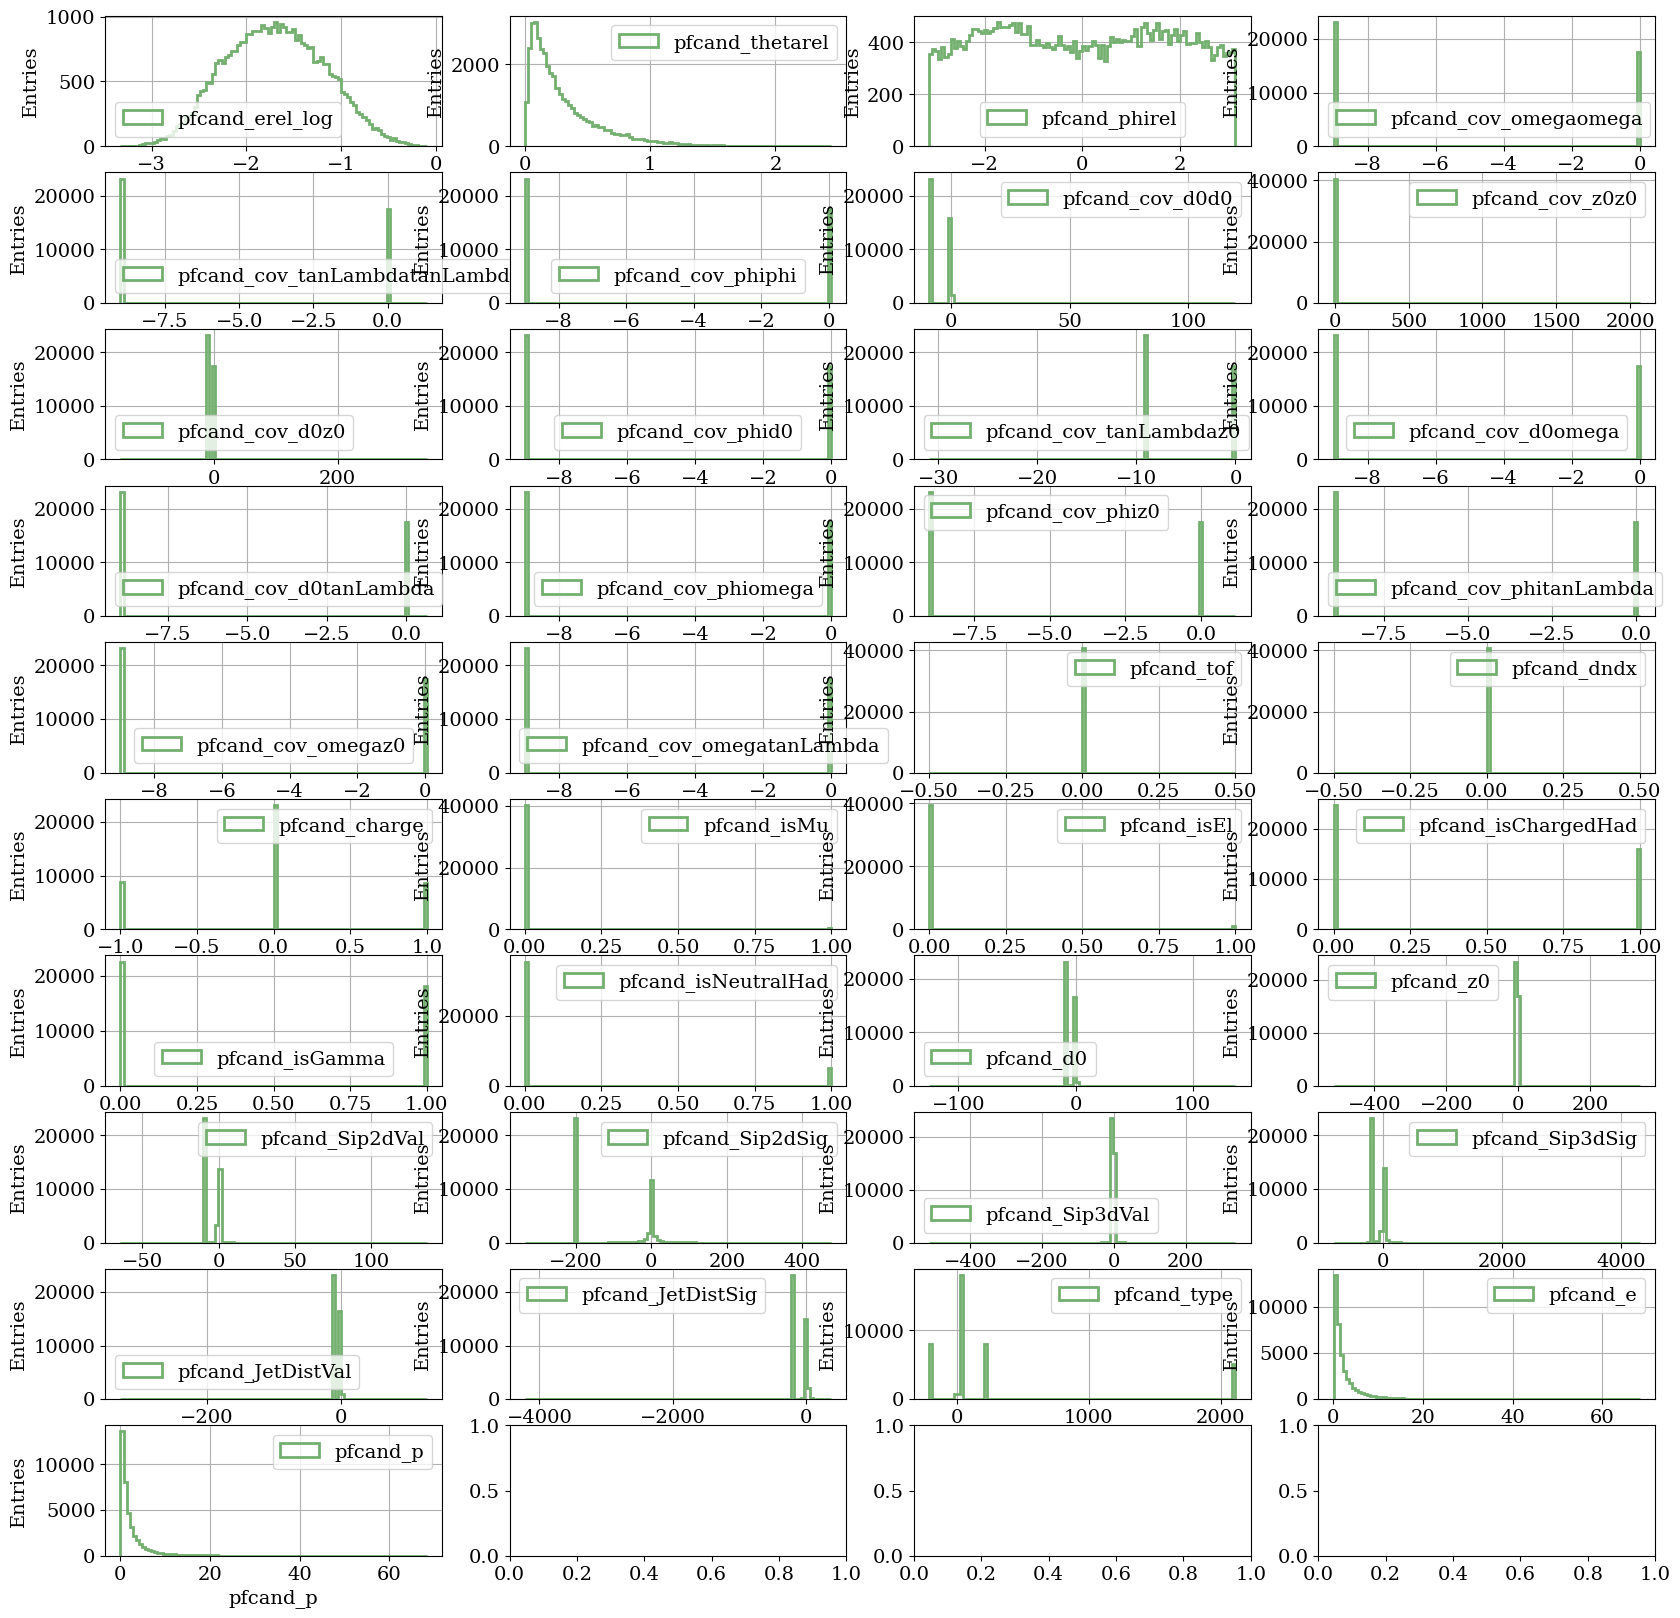

In [48]:
# print histograms of all the extra pfcand variables
fig, axs = plt.subplots(10, 4, figsize=(20,20))
keys = list(pfcand_FCCAnalyses_minus.keys())
print("keys of pfcand_FCCAnalyses_minus:", keys)
for i, ax in enumerate(axs.flat):
    if i >= len(pfcand_FCCAnalyses_minus.keys()):
        break
    ax.hist(pfcand_FCCAnalyses_minus[keys[i]], bins=100, histtype="step", label=keys[i], density=False, linewidth=2.0)
    ax.set_xlabel(key)
    ax.set_ylabel("Entries")
    ax.legend()
    ax.grid(True)